BOOKS DATA ANALYSIS

In [1]:
# important libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:/Users/HP - Vicus/OneDrive/Desktop/web scraping/books.csv")

In [3]:
df.shape

(1000, 15)

In [5]:
df.columns.tolist()

['title',
 'price',
 'rating',
 'Availability',
 'Stock_Count',
 'Category',
 'UPC',
 'Product_Type',
 'Price_Excl_Tax',
 'Price_Incl_Tax',
 'Tax',
 'Number_of_Reviews',
 'Description',
 'Product_URL',
 'Image_URL']

In [6]:
df.head()

,title,price,rating,Availability,Stock_Count,Category,UPC,Product_Type,Price_Excl_Tax,Price_Incl_Tax,Tax,Number_of_Reviews,Description,Product_URL,Image_URL
0,A Light in the Attic,51.77,3,In stock (22 available),22,Poetry,a897fe39b1053632,Books,51.77,51.77,0.0,0,It's hard to imagine a world without A Light i...,https://books.toscrape.com/catalogue/a-light-i...,https://books.toscrape.com/media/cache/fe/72/f...
1,Tipping the Velvet,53.74,1,In stock (20 available),20,Historical Fiction,90fa61229261140a,Books,53.74,53.74,0.0,0,"""Erotic and absorbing...Written with starling ...",https://books.toscrape.com/catalogue/tipping-t...,https://books.toscrape.com/media/cache/08/e9/0...
2,Soumission,50.10,1,In stock (20 available),20,Fiction,6957f44c3847a760,Books,50.10,50.10,0.0,0,"Dans une France assez proche de la nôtre, un h...",https://books.toscrape.com/catalogue/soumissio...,https://books.toscrape.com/media/cache/ee/cf/e...
3,Sharp Objects,47.82,4,In stock (20 available),20,Mystery,e00eb4fd7b871a48,Books,47.82,47.82,0.0,0,"WICKED above her hipbone, GIRL across her hear...",https://books.toscrape.com/catalogue/sharp-obj...,https://books.toscrape.com/media/cache/c0/59/c...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock (20 available),20,History,4165285e1663650f,Books,54.23,54.23,0.0,0,From a renowned historian comes a groundbreaki...,https://books.toscrape.com/catalogue/sapiens-a...,https://books.toscrape.com/media/cache/ce/5f/c...


In [10]:
df.dtypes

title                    str
price                float64
rating                 int64
Availability             str
Stock_Count            int64
Category                 str
UPC                      str
Product_Type             str
Price_Excl_Tax       float64
Price_Incl_Tax       float64
Tax                  float64
Number_of_Reviews      int64
Description              str
Product_URL              str
Image_URL                str
dtype: object

In [11]:
# Missing values
df.isnull().sum()

title                0
price                0
rating               0
Availability         0
Stock_Count          0
Category             0
UPC                  0
Product_Type         0
Price_Excl_Tax       0
Price_Incl_Tax       0
Tax                  0
Number_of_Reviews    0
Description          2
Product_URL          0
Image_URL            0
dtype: int64

In [14]:
# Handle missing values in the Description column
df['Description'] = df['Description'].fillna('No description')

In [19]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [20]:
# clean text columns
text_column=[
    'title',
    'Availability',
    'Category',
    'UPC',
    'Product_Type',
    'Description',
    'Product_URL',
    'Image_URL'
]
for col in text_column:
    df[col] = df[col].astype(str).str.strip()

In [22]:
# Statistics
df.describe()

,price,rating,Stock_Count,Price_Excl_Tax,Price_Incl_Tax,Tax,Number_of_Reviews
count,1000.00000,1000.000000,1000.000000,1000.00000,1000.00000,1000.0,1000.0
mean,35.07035,2.923000,8.585000,35.07035,35.07035,0.0,0.0
std,14.44669,1.434967,5.654622,14.44669,14.44669,0.0,0.0
min,10.00000,1.000000,1.000000,10.00000,10.00000,0.0,0.0
25%,22.10750,2.000000,3.000000,22.10750,22.10750,0.0,0.0
50%,35.98000,3.000000,7.000000,35.98000,35.98000,0.0,0.0
75%,47.45750,4.000000,14.000000,47.45750,47.45750,0.0,0.0
max,59.99000,5.000000,22.000000,59.99000,59.99000,0.0,0.0


In [24]:
# Category Analysis
category_counts = df['Category'].value_counts()
category_counts.head(10)

Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            48
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64

In [26]:
# Rating Analysis
rating_counts = df['rating'].value_counts().sort_index()
rating_counts

rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

In [27]:
# Price Analysis
print(f'Average price: {round(df['price'].mean(),2)}')
print(f'Minimum price: {df['price'].min()}')
print(f'Maxmum Price: {df['price'].max()}')
print(f'Median price: {df['price'].median()}')

Average price: 35.07
Minimum price: 10.0
Maxmum Price: 59.99
Median price: 35.980000000000004


In [32]:
# Most expensive books
exbensive_book = df.sort_values(by=['price'], ascending=False)[['title','price','rating','Category','UPC']]
print("TOP 10 MOST EXPENSIVE BOOKS:")
exbensive_book.head(10)

TOP 10 MOST EXPENSIVE BOOKS:


,title,price,rating,Category,UPC
648,The Perfect Play (Play by Play #1),59.99,3,Romance,9cc207168a03470d
617,Last One Home (New Beginnings #1),59.98,3,Fiction,07e6810fd3236bda
860,Civilization and Its Discontents,59.95,2,Psychology,396385e3de5d18c3
560,The Barefoot Contessa Cookbook,59.92,5,Food and Drink,6478ccb4416e6a5d
366,The Diary of a Young Girl,59.90,3,Nonfiction,54fc03f1e1d355db
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3,Thriller,9c4d061c1e2fe6bf
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1,History,de3f25248ba0789f
387,Boar Island (Anna Pigeon #19),59.48,3,Mystery,49b24c6a41b82bd2
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,Nonfiction,60376aa71be66083
393,The Improbability of Love,59.45,1,Fiction,437d8dea9272d0a9


In [31]:
# cheapest books
cheapest_book = df.sort_values(by = ['price'])[['title','price','rating','Category','UPC']]
print("TOP 10 CHEAPEST BOOKS")
cheapest_book.head(10)

TOP 10 CHEAPEST BOOKS


,title,price,rating,Category,UPC
638,An Abundance of Katherines,10.00,5,Young Adult,f36d24c309e87e5b
501,The Origin of Species,10.01,4,Science,0345872b14f9e774
716,The Tipping Point: How Little Things Can Make ...,10.02,2,Add a comment,224fa77d4b248046
84,Patience,10.16,3,Sequential Art,9429b4d59c537af5
302,Greek Mythic History,10.23,5,Default,f201f263d8c23f97
558,The Fellowship of the Ring (The Lord of the Ri...,10.27,2,Default,cb17945cb90b7837
479,History of Beauty,10.29,4,Art,8a150fd8ff5d7686
242,The Lucifer Effect: Understanding How Good Peo...,10.40,1,Psychology,4e812d32d64e2431
434,"NaNo What Now? Finding your editing process, r...",10.41,4,Default,ee6c67859d70186b
274,Pet Sematary,10.56,3,Horror,af58a74e4b2a23a0


In [37]:
# Category Price Analysis
category_price = (df.groupby('Category')['price']
.agg(['count','mean','min','max']).sort_values(by = ['mean'], ascending = False))
print('Price by category')
category_price.head(10)

Price by category


,count,mean,min,max
Category,,,,
Suspense,1,58.330000,58.33,58.33
Novels,1,54.810000,54.81,54.81
Politics,3,53.613333,51.33,56.86
Health,4,51.452500,49.05,54.07
New Adult,6,46.383333,36.29,58.35
Christian,3,42.496667,25.77,54.00
Sports and Games,5,41.166000,24.42,51.22
Self Help,5,40.620000,12.08,52.15
Travel,11,39.794545,23.21,56.88


In [41]:
# Rating Price Analysis
rating_price= (df.groupby('rating')['price'].agg(['count','mean','min','max']))
print('Rating by price')
rating_price.head()

Rating by price


,count,mean,min,max
rating,,,,
1,226,34.561195,10.40,59.64
2,196,34.810918,10.02,59.95
3,203,34.692020,10.16,59.99
4,179,36.093296,10.01,59.45
5,196,35.374490,10.00,59.92


In [43]:
# Stock Analysis
df["Stock_Count"].describe()

count    1000.000000
mean        8.585000
std         5.654622
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        22.000000
Name: Stock_Count, dtype: float64

In [45]:
# Book with the highest stock
highest_stock = df.sort_values(by = ['Stock_Count'], ascending = False)[["title", "Stock_Count", "price", "Category"]]
print('Top 10 books by stock:')
highest_stock.head(10)

Top 10 books by stock:


,title,Stock_Count,price,Category
0,A Light in the Attic,22,51.77,Poetry
1,Tipping the Velvet,20,53.74,Historical Fiction
2,Soumission,20,50.10,Fiction
3,Sharp Objects,20,47.82,Mystery
4,Sapiens: A Brief History of Humankind,20,54.23,History
5,The Requiem Red,19,22.65,Young Adult
6,The Dirty Little Secrets of Getting Your Dream...,19,33.34,Business
7,The Coming Woman: A Novel Based on the Life of...,19,17.93,Default
8,The Boys in the Boat: Nine Americans and Their...,19,22.60,Default
9,The Black Maria,19,52.15,Poetry


In [53]:
sns.set_theme(style="whitegrid")

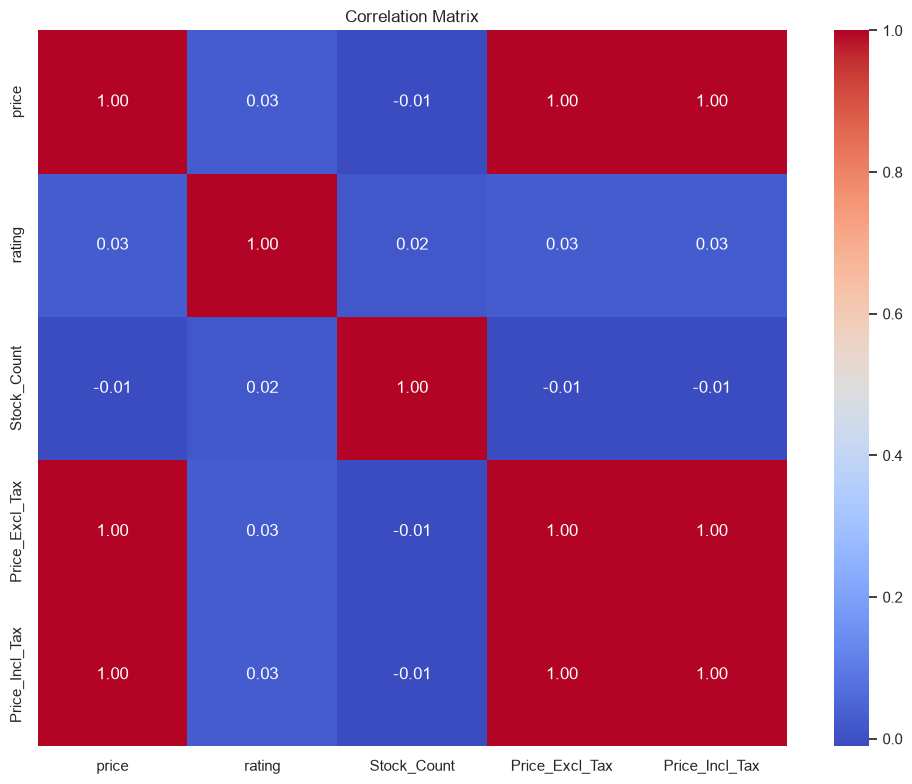

In [57]:
# Correlation Heatmap
corr_col = [
    'price',
    'rating',
    'Stock_Count',
    'Price_Excl_Tax',
    'Price_Incl_Tax'

]
correlation = df[corr_col].corr()
correlation
plt.figure(figsize = (10,8))
sns.heatmap(correlation,annot = True, cmap = 'coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(
    "correlation_matrix.png",
    dpi=300)
plt.show()

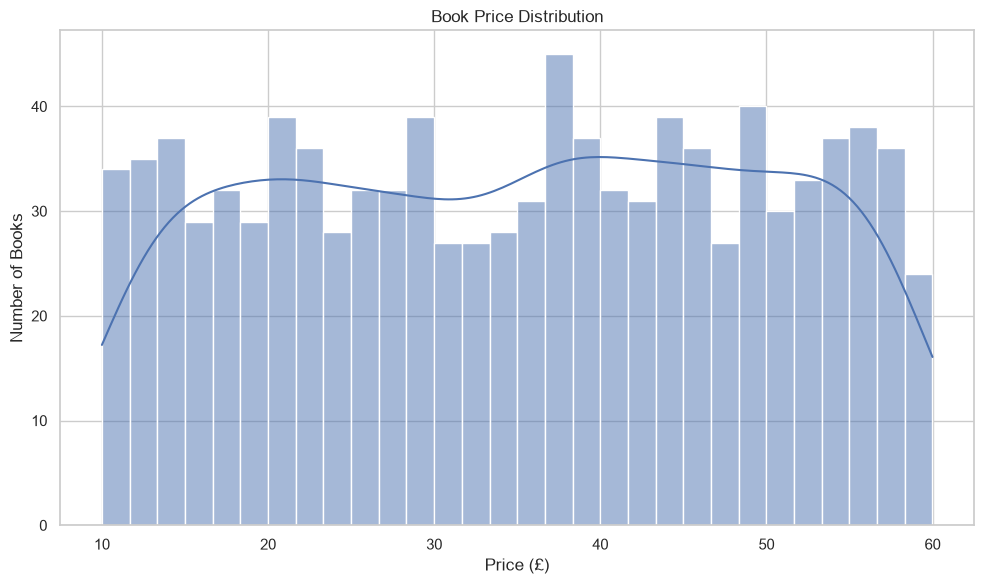

In [60]:
# Price Distribution
plt.figure(figsize = (10,6))
sns.histplot(df['price'],bins = 30, kde = True)
plt.title('Book Price Distribution')
plt.xlabel("Price (£)")
plt.ylabel('Number of Books')
plt.tight_layout()
plt.savefig(
    "price_distribution.png",
    dpi=300
)

plt.show()

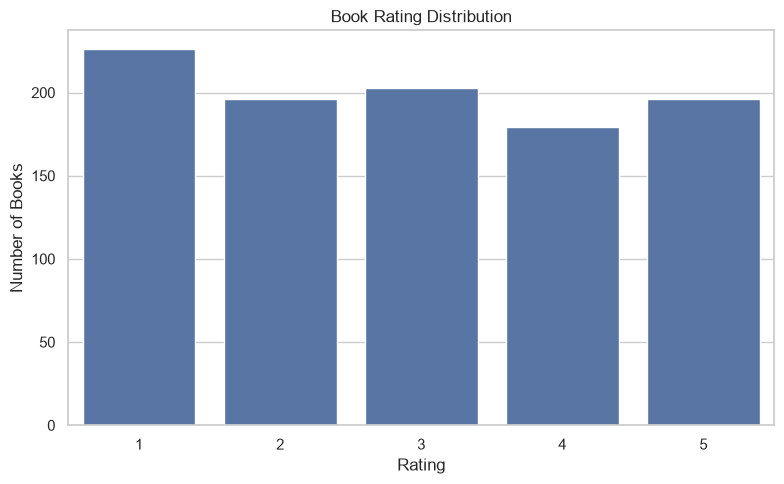

In [69]:
# Rating Distribution
plt.figure(figsize = (8,5))
sns.countplot(x=df['rating'])
plt.title('Book Rating Distribution')
plt.xlabel("Rating")
plt.ylabel('Number of Books')
plt.tight_layout()
plt.savefig(
     "rating_distribution.png",
    dpi=300
)
plt.show()

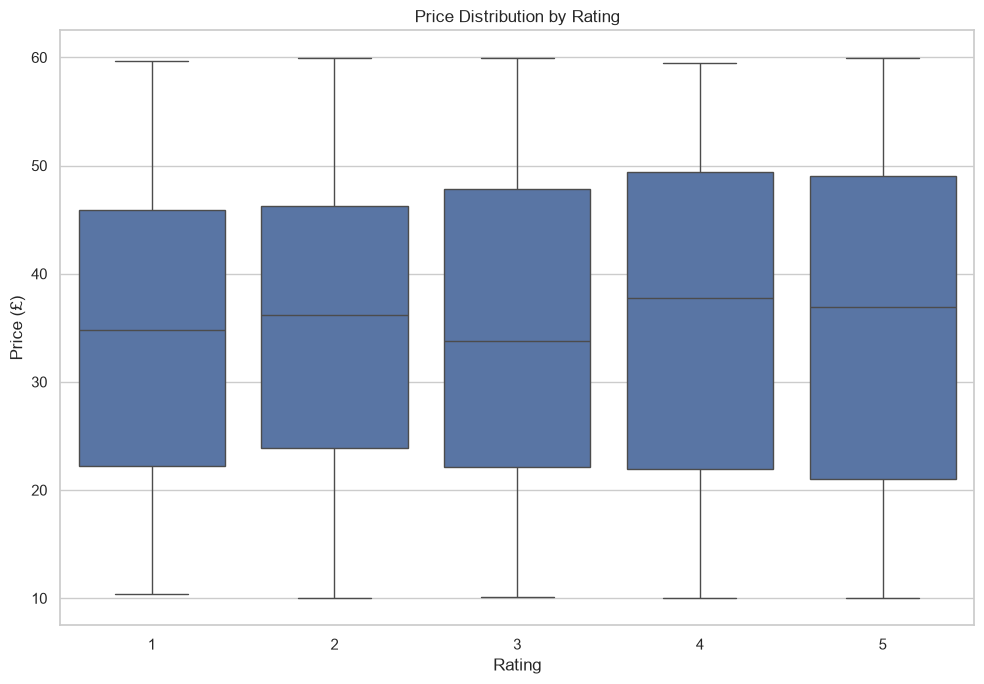

In [70]:
# Price Distribution by Rating
plt.figure(figsize = (10,7))
sns.boxplot(x=df['rating'], y=df['price'])
plt.title('Price Distribution by Rating')
plt.xlabel("Rating")
plt.ylabel('Price (£)')
plt.tight_layout()
plt.savefig(
"price_by_rating.png",
    dpi=300)
plt.show()

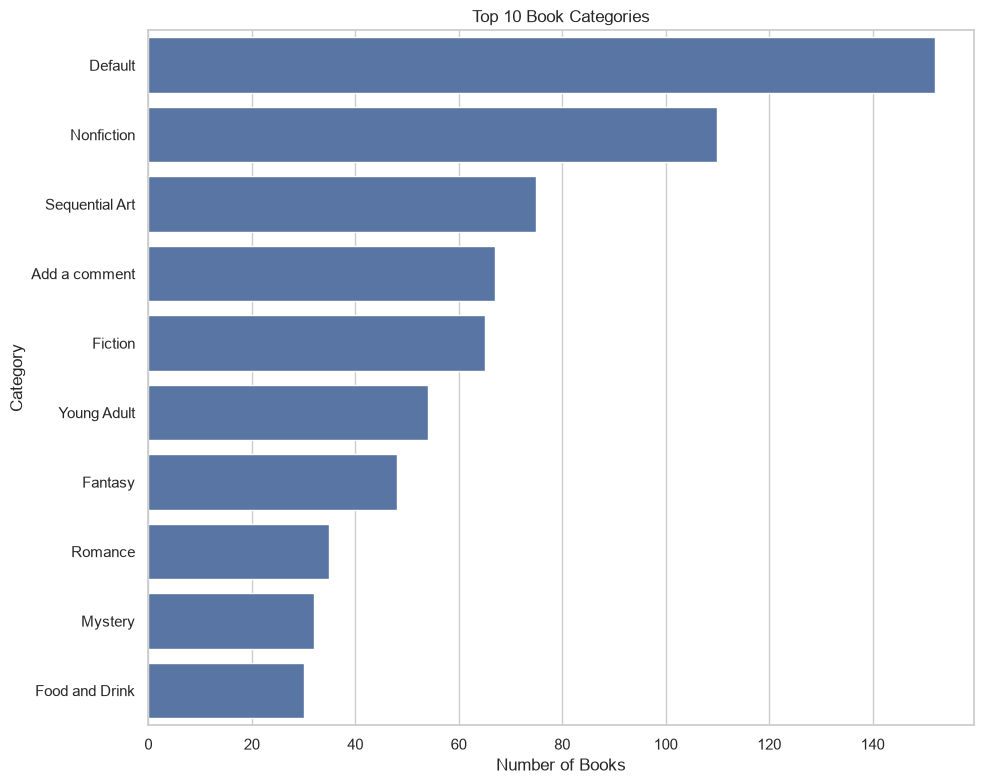

In [71]:
# Top Categories
top_categories = (df['Category'].value_counts().head(10))
plt.figure(figsize = (10,8))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title("Top 10 Book Categories")
plt.xlabel("Number of Books")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(
    "top_categories.png",
    dpi=300)
plt.show()

In [72]:
# Save Clean Dataset
df.to_csv(
    "books_cleaned.csv",
    index=False,
    encoding="utf-8"
)

print("Clean dataset saved as books_cleaned.csv")

print("Analysis completed successfully!")

Clean dataset saved as books_cleaned.csv
Analysis completed successfully!
